[TEMPatchDataset] 2269 patches from 11 images


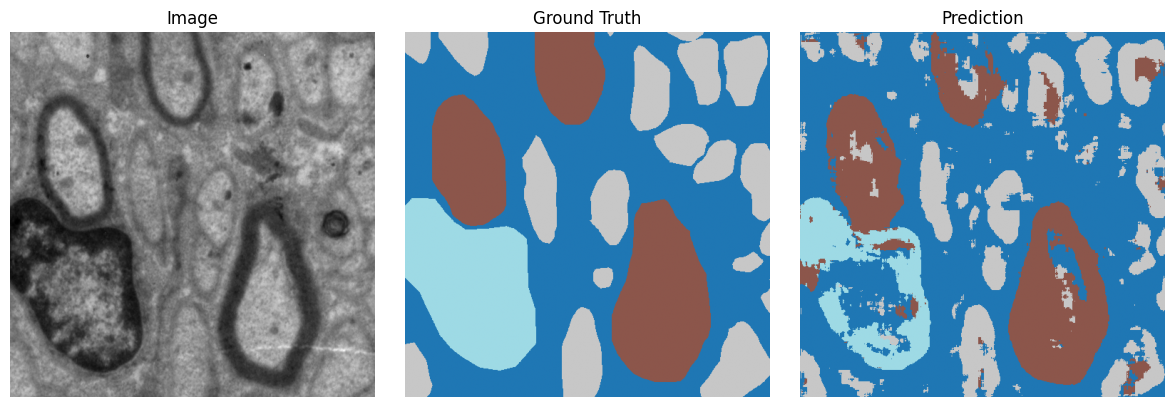

Unique classes in pred: tensor([0, 2, 3, 4])
Unique classes in GT: tensor([0, 2, 3, 4])


In [ ]:
import torch
import matplotlib.pyplot as plt

from src.datasets.tem_dataset import TEMPatchDataset
from src.models.unet_small import UNetSmall
from src.models.attention_unet import AttentionUNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load dataset (same settings as training)
h5_path = "data/train/train_data.h5"
patch_size = 512

# By default this should give you tensors:
#   img:  (1, H, W)  - single-channel
#   mask: (H, W)     - class indices
ds = TEMPatchDataset(h5_path, patch_size=patch_size, stride=patch_size)

# 2. Load model weights
# model = UNetSmall(in_ch=1, n_classes=5).to(device)
# model.load_state_dict(torch.load("tem_unet_small_best.pth", map_location=device))
# model.eval()

model = AttentionUNet(in_ch=1, n_classes=5).to(device)
model.load_state_dict(torch.load("tem_attention_unet_best.pth", map_location=device))
model.eval()

# 3. Take one patch and run inference
img, mask = ds[1222]              # img: (1, H, W), mask: (H, W)

# Prepare input for model: add batch dim -> (1, 1, H, W)
x = img.unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)                               # (1, 5, H, W)
    pred = logits.argmax(1).squeeze(0).cpu()        # (H, W) predicted labels

# 4. Convert to numpy for plotting
img_np  = img.squeeze(0).detach().cpu().numpy()     # (H, W) for imshow
mask_np = mask.detach().cpu().numpy()              # (H, W)
pred_np = pred.detach().cpu().numpy()              # (H, W)

# 5. Plot original image, GT mask, prediction
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(mask_np, cmap="tab20")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Prediction")
plt.imshow(pred_np, cmap="tab20")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Unique classes in pred:", torch.unique(pred))
print("Unique classes in GT:", torch.unique(mask))



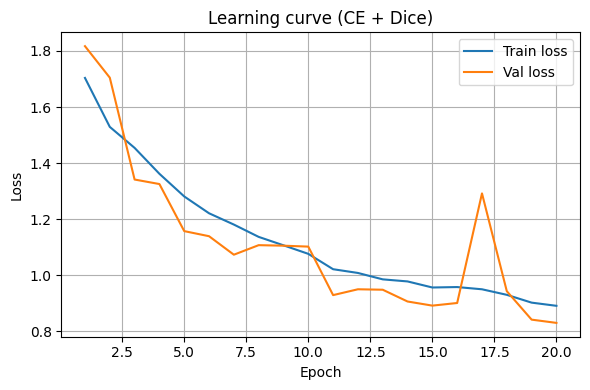

In [15]:
import json
import matplotlib.pyplot as plt

with open("loss_history.json", "r") as f:
    hist = json.load(f)

train_losses = hist["train_losses"]
val_losses = hist["val_losses"]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curve (CE + Dice)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()